# Evaluation and Backtesting

This notebook focuses on:

- reviewing saved model outputs
- comparing final model performance
- checking prediction quality visually
- running a simple strategy-style backtest

In [27]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [28]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [29]:
import pandas as pd

from src.evaluation.backtest import backtest_predictions
from src.utils.plotting import (
    plot_actual_vs_predicted,
    plot_cumulative_returns,
    plot_model_comparison,
)

In [30]:
ml_results = pd.read_csv("../outputs/results/ml_model_results.csv")
arima_results = pd.read_csv("../outputs/results/arima_results.csv")
lstm_results = pd.read_csv("../outputs/results/lstm_results.csv")
final_results = pd.read_csv("../outputs/results/final_model_comparison.csv")

In [31]:
final_results

,model,cv_mse_mean,cv_mse_std,train_mse,test_mse,test_rmse,test_mae,directional_accuracy
0,ARIMA,NaN,NaN,1.014732e-03,0.000875,0.029584,0.021116,0.621622
1,LASSO,0.001160,0.000749,1.046235e-03,0.000896,0.029930,0.021071,0.648649
2,EN,0.001160,0.000749,1.046235e-03,0.000896,0.029930,0.021071,0.648649
3,KNN,0.001211,0.000650,8.538625e-04,0.001022,0.031963,0.023879,0.513514
4,ETR,0.001328,0.000682,2.369418e-33,0.001063,0.032604,0.025006,0.513514
5,LR,0.003945,0.003637,8.952284e-04,0.001097,0.033115,0.026606,0.432432
6,ABR,0.001309,0.000637,3.900237e-04,0.001232,0.035105,0.028667,0.432432
7,GBR,0.001541,0.000807,3.475691e-05,0.001272,0.035667,0.028863,0.459459
8,XGB,0.001408,0.000749,1.625689e-04,0.001298,0.036028,0.028634,0.378378
9,RFR,0.001344,0.000714,1.572199e-04,0.001360,0.036875,0.029797,0.378378


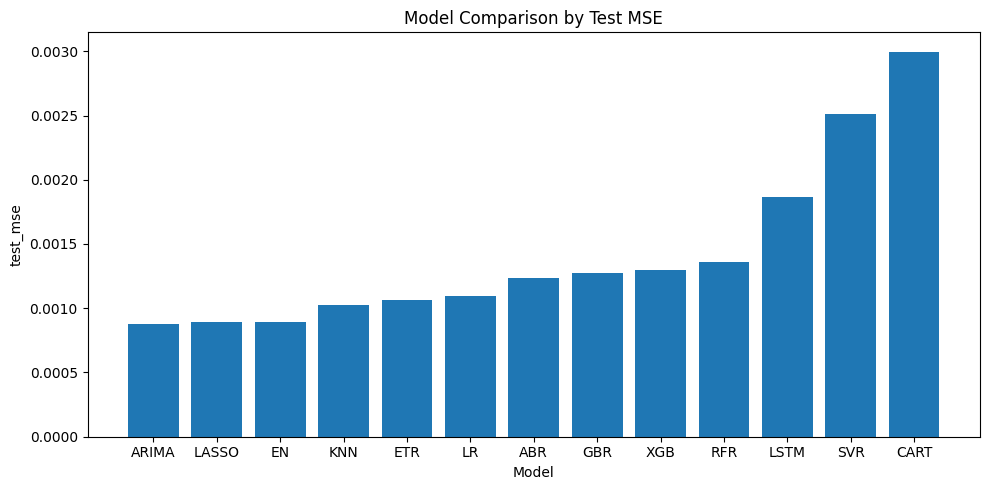

In [32]:
from src.utils.config import FIGURES_DIR
plot_model_comparison(final_results, metric="test_mse", title="Model Comparison by Test MSE", save_path=FIGURES_DIR / "model_comparison_mse.png")

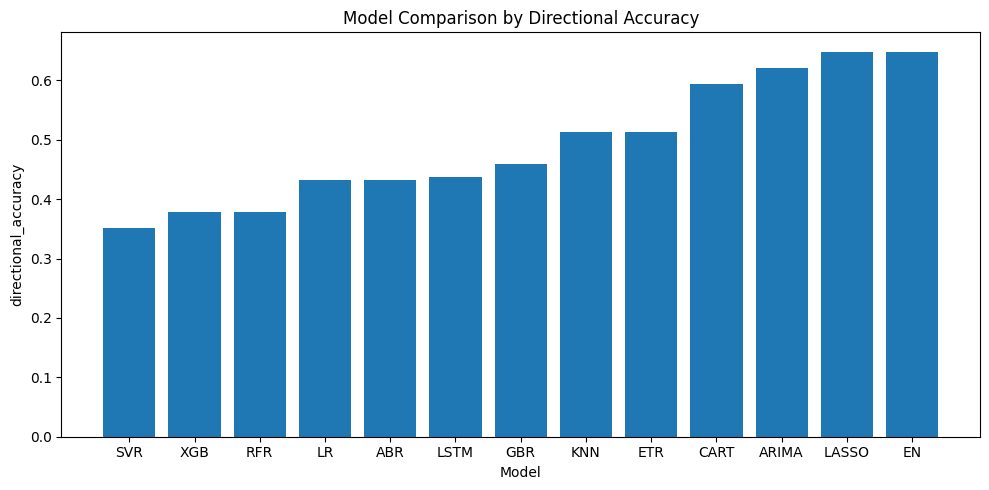

In [33]:
plot_model_comparison(final_results, metric="directional_accuracy", title="Model Comparison by Directional Accuracy")

## Load Predictions
I now inspect the predictions from ARIMA and LSTM directly.

In [34]:
arima_predictions = pd.read_csv("../outputs/results/arima_predictions.csv", index_col=0, parse_dates=True)
lstm_predictions = pd.read_csv("../outputs/results/lstm_predictions.csv")

In [35]:
arima_predictions.head()

,actual,predicted
2019-04-05,0.009268,-0.000841
2019-04-12,0.025061,0.006006
2019-04-22,0.033290,0.004165
2019-04-29,-0.082580,0.002135
2019-05-06,-0.048824,0.000765


In [36]:
lstm_predictions.head()

,actual,predicted
0,0.007075,0.007384
1,-0.004466,0.011553
2,-0.077585,-0.010596
3,0.024866,-0.052188
4,0.022139,-0.031477


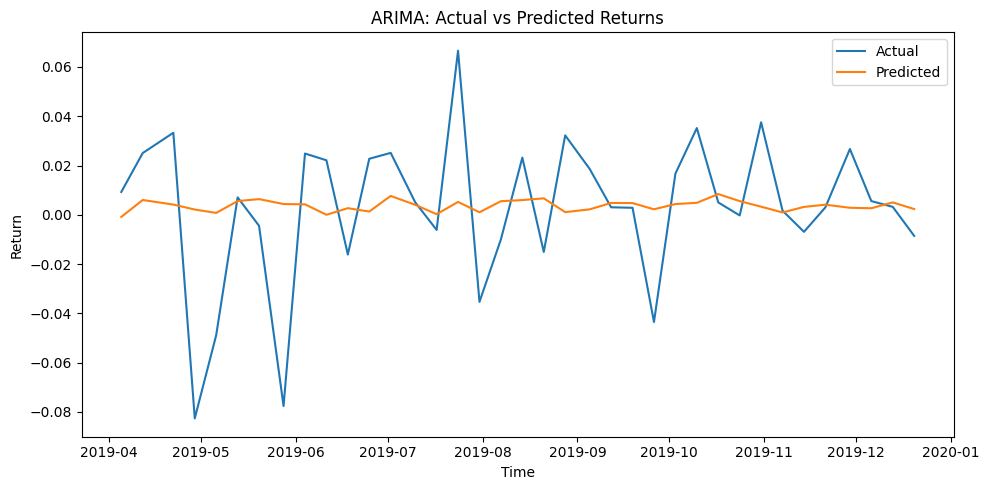

In [37]:
plot_actual_vs_predicted(
    arima_predictions["actual"],
    arima_predictions["predicted"],
    title="ARIMA: Actual vs Predicted Returns",
    save_path=FIGURES_DIR / "arima_actual_vs_pred.png"
)

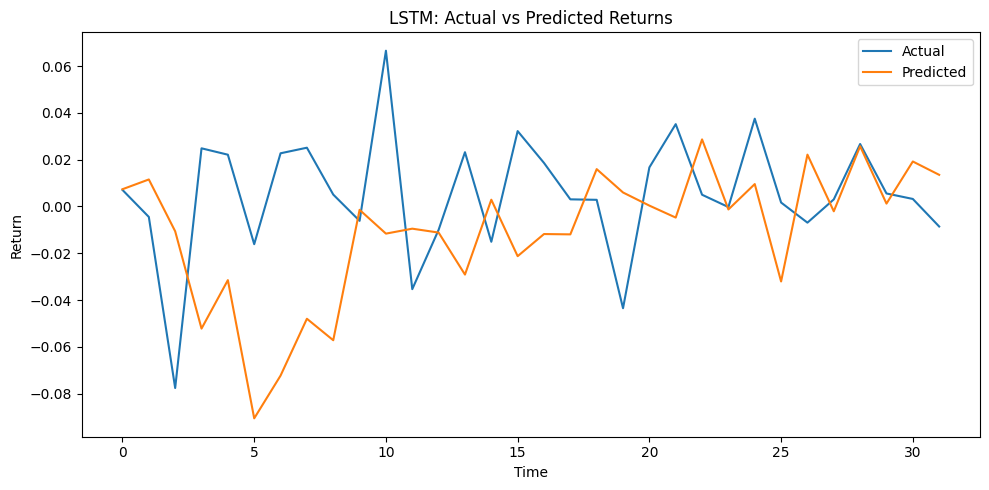

In [38]:
plot_actual_vs_predicted(
    lstm_predictions["actual"],
    lstm_predictions["predicted"],
    title="LSTM: Actual vs Predicted Returns"
)

## Simple Backtest
I apply a simple rule:

- go long if predicted return > 0
- go short otherwise

This is only a simple directional test, not a full trading system.

In [39]:
arima_backtest_results, arima_history = backtest_predictions(
    arima_predictions["actual"],
    arima_predictions["predicted"]
)

arima_backtest_results

{'strategy_total_return': 0.06731257154855053,
 'buy_and_hold_return': 0.08728147273304665,
 'strategy_sharpe': 0.07408285846071,
 'buy_and_hold_sharpe': 0.09093460376810636,
 'strategy_max_drawdown': -0.19300018336259933,
 'buy_and_hold_max_drawdown': -0.1930001833625993}

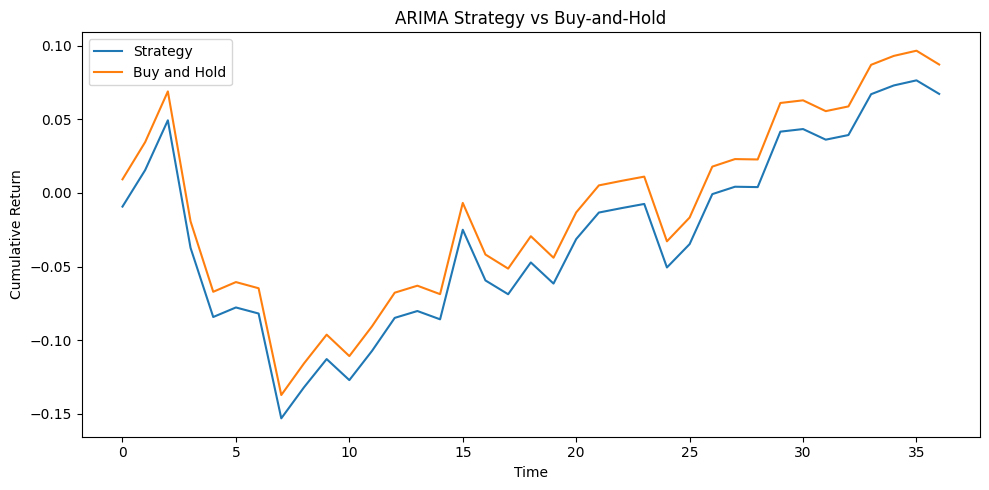

In [40]:
plot_cumulative_returns(
    arima_history,
    title="ARIMA Strategy vs Buy-and-Hold",
    save_path=FIGURES_DIR / "arima_backtest.png"
)

In [41]:
lstm_backtest_results, lstm_history = backtest_predictions(
    lstm_predictions["actual"],
    lstm_predictions["predicted"]
)

lstm_backtest_results

{'strategy_total_return': -0.11589047695678811,
 'buy_and_hold_return': 0.16556015847361216,
 'strategy_sharpe': -0.1336196227429875,
 'buy_and_hold_sharpe': 0.1982070388821836,
 'strategy_max_drawdown': -0.22698217249856642,
 'buy_and_hold_max_drawdown': -0.08170415000143676}

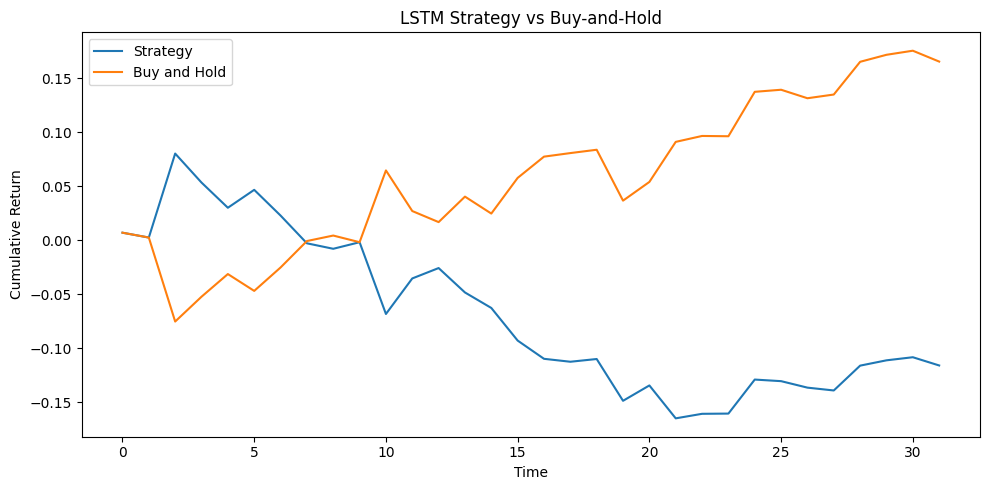

In [42]:
plot_cumulative_returns(
    lstm_history,
    title="LSTM Strategy vs Buy-and-Hold"
)

## Final Conclusions

Some main conclusions from the project:

- ARIMA and regularized linear models performed best on this dataset
- LSTM did not improve results, likely because the dataset is small and noisy
- lower model complexity was not a disadvantage here
- evaluating financial forecasts only by regression error is incomplete, so directional and strategy-style checks were also useful
- this project shows that careful baselines can be stronger than jumping directly to deep learning